<a href="https://colab.research.google.com/github/chandrakant1212/chandrakant1212/blob/main/Assignment1_DAI_101.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, chi2_contingency
from mpl_toolkits.mplot3d import Axes3D

In [3]:
sns.set(style='whitegrid', context='notebook')

In [4]:
df = pd.read_csv('https://raw.githubusercontent.com/dataprofessor/data/refs/heads/master/delaney_solubility_with_descriptors.csv')
print('Dataset loaded successfully with shape:', df.shape)
print(df.head())

Dataset loaded successfully with shape: (1144, 5)
   MolLogP    MolWt  NumRotatableBonds  AromaticProportion  logS
0   2.5954  167.850                0.0                 0.0 -2.18
1   2.3765  133.405                0.0                 0.0 -2.00
2   2.5938  167.850                1.0                 0.0 -1.74
3   2.0289  133.405                1.0                 0.0 -1.48
4   2.9189  187.375                1.0                 0.0 -3.04


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1144 entries, 0 to 1143
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   MolLogP             1144 non-null   float64
 1   MolWt               1144 non-null   float64
 2   NumRotatableBonds   1144 non-null   float64
 3   AromaticProportion  1144 non-null   float64
 4   logS                1144 non-null   float64
dtypes: float64(5)
memory usage: 44.8 KB


In [6]:
print('Missing values in each column:')
print(df.isnull().sum())

Missing values in each column:
MolLogP               0
MolWt                 0
NumRotatableBonds     0
AromaticProportion    0
logS                  0
dtype: int64


# Data Cleaning

In [7]:
df.fillna(df.median(), inplace=True)

# UNIVARIATE ANALYSIS

In [8]:
print(df.describe())

           MolLogP        MolWt  NumRotatableBonds  AromaticProportion  \
count  1144.000000  1144.000000        1144.000000         1144.000000   
mean      2.449133   204.631675           2.173951            0.364932   
std       1.866003   102.620500           2.627398            0.343305   
min      -7.571400    16.043000           0.000000            0.000000   
25%       1.414900   122.126000           0.000000            0.000000   
50%       2.340300   183.594500           1.000000            0.375000   
75%       3.406475   270.715750           3.000000            0.666667   
max      10.388600   780.949000          23.000000            1.000000   

              logS  
count  1144.000000  
mean     -3.057997  
std       2.096502  
min     -11.600000  
25%      -4.332250  
50%      -2.870500  
75%      -1.600000  
max       1.580000  


# Histograms for all numeric variables

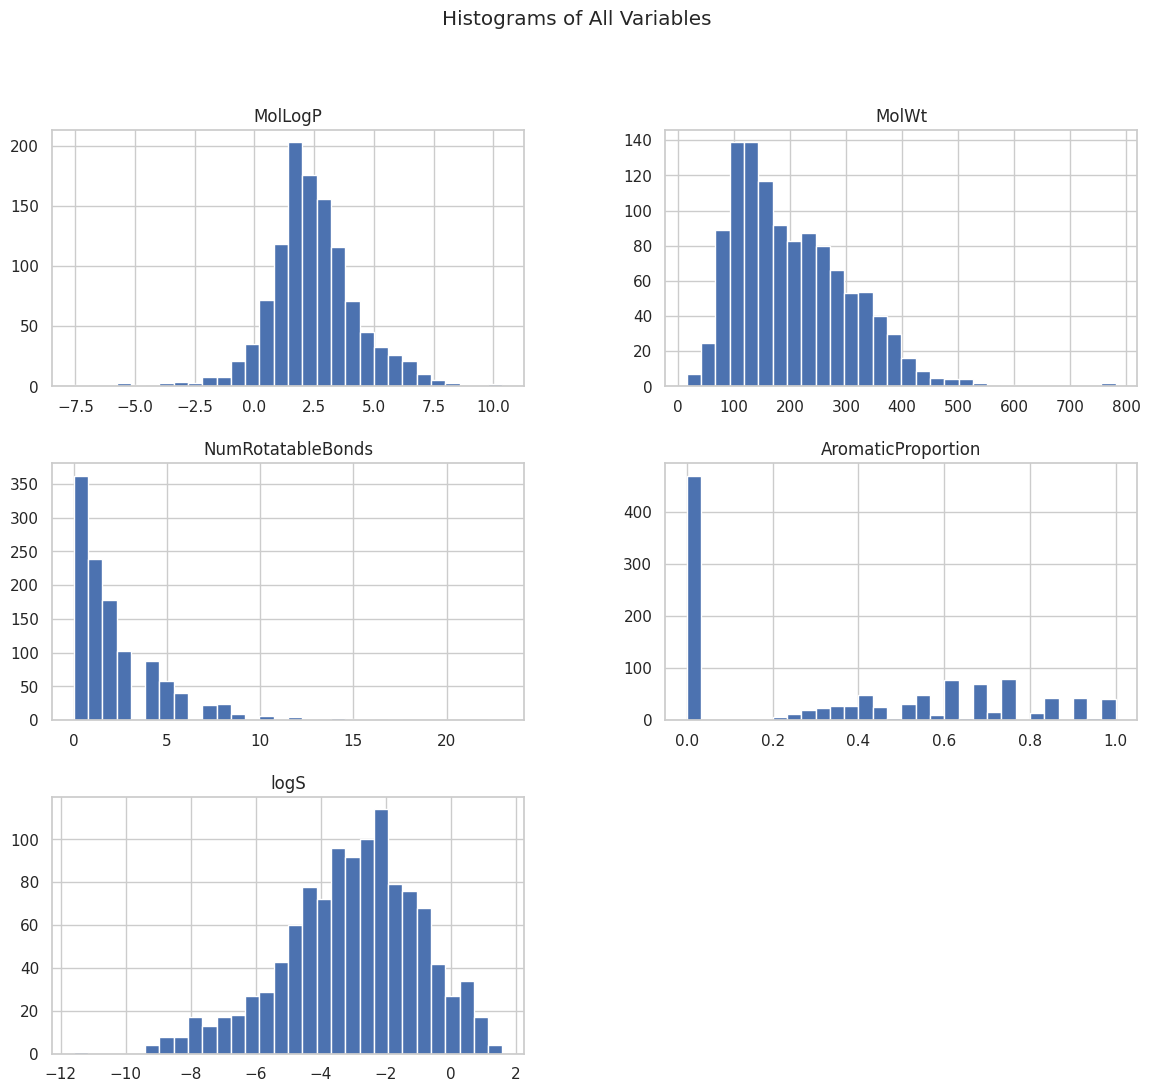

In [9]:
df.hist(figsize=(14, 12), bins=30)
plt.suptitle('Histograms of All Variables')
plt.show()

# Box plots

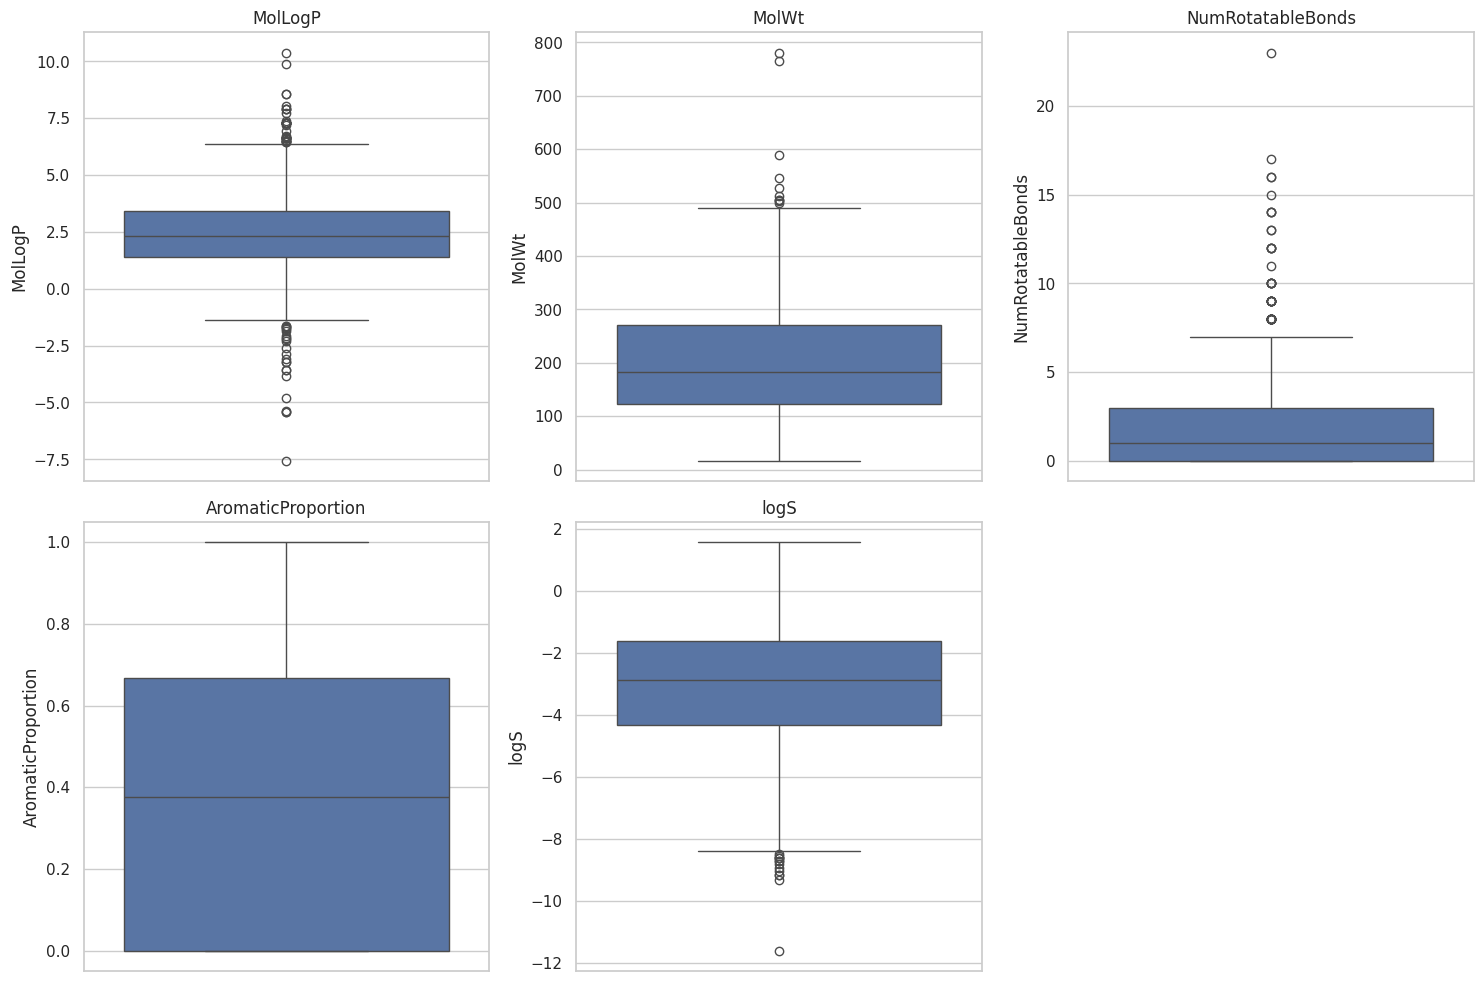

In [10]:
plt.figure(figsize=(15, 10))
numeric_cols = df.select_dtypes(include=[np.number]).columns
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# Violin plots

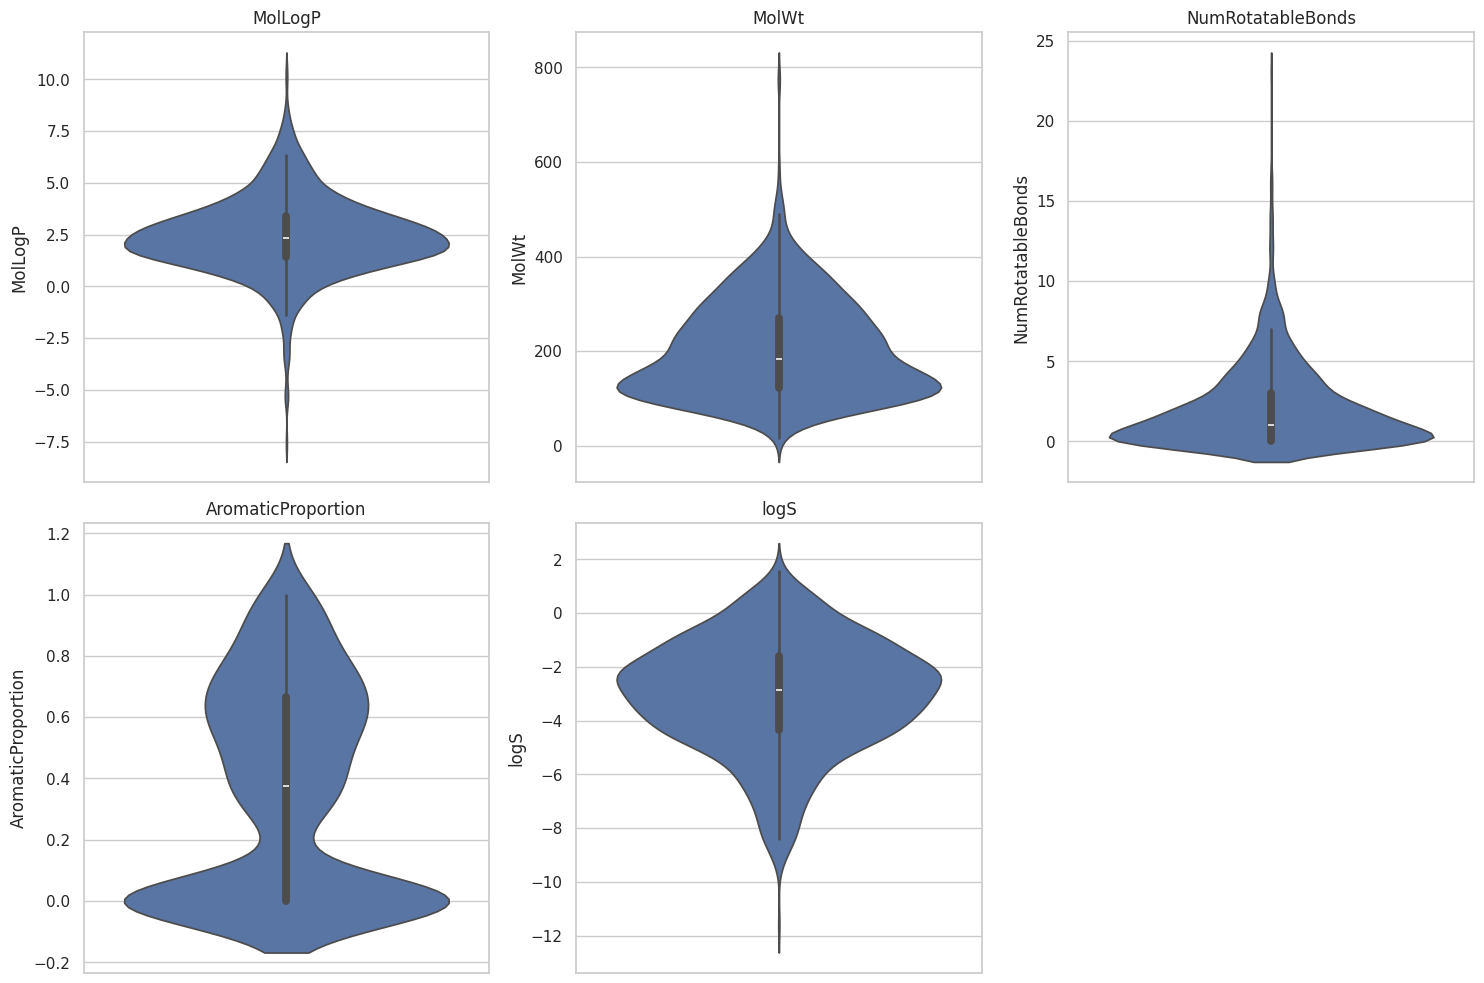

In [11]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.violinplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# Skewness and Kurtosis

In [12]:
print("Skewness and Kurtosis:")
for col in numeric_cols:
    print(f'{col}: Skewness = {skew(df[col])}, Kurtosis = {kurtosis(df[col])}')

Skewness and Kurtosis:
MolLogP: Skewness = -0.01296513214694116, Kurtosis = 2.4881156615279796
MolWt: Skewness = 0.8893087911387616, Kurtosis = 1.2006569714187405
NumRotatableBonds: Skewness = 2.1553469325812156, Kurtosis = 7.4656953957553185
AromaticProportion: Skewness = 0.22600553751344823, Kurtosis = -1.413589090080197
logS: Skewness = -0.4839545835670128, Kurtosis = 0.16414203376299952


# Kernel Density Distribution

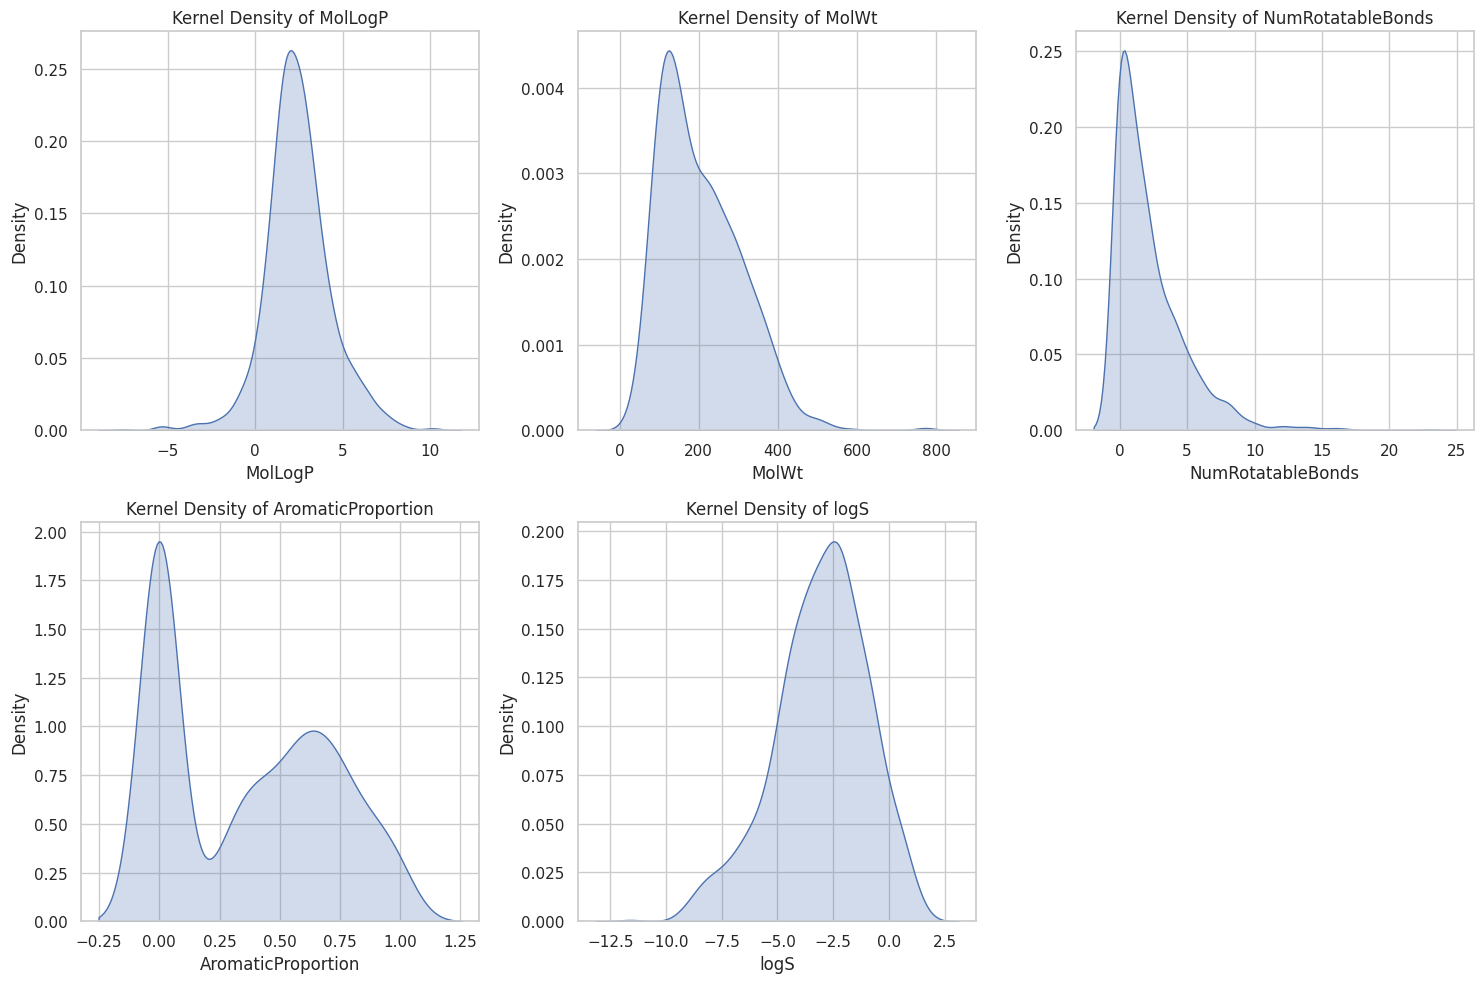

In [13]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.kdeplot(df[col], fill=True)
    plt.title(f'Kernel Density of {col}')
plt.tight_layout()
plt.show()

# Data Distribution

### Distribution Plots for Target Variable: Visualize the distribution of the target variable 'logS' using a histogram and a KDE plot to understand its distribution.

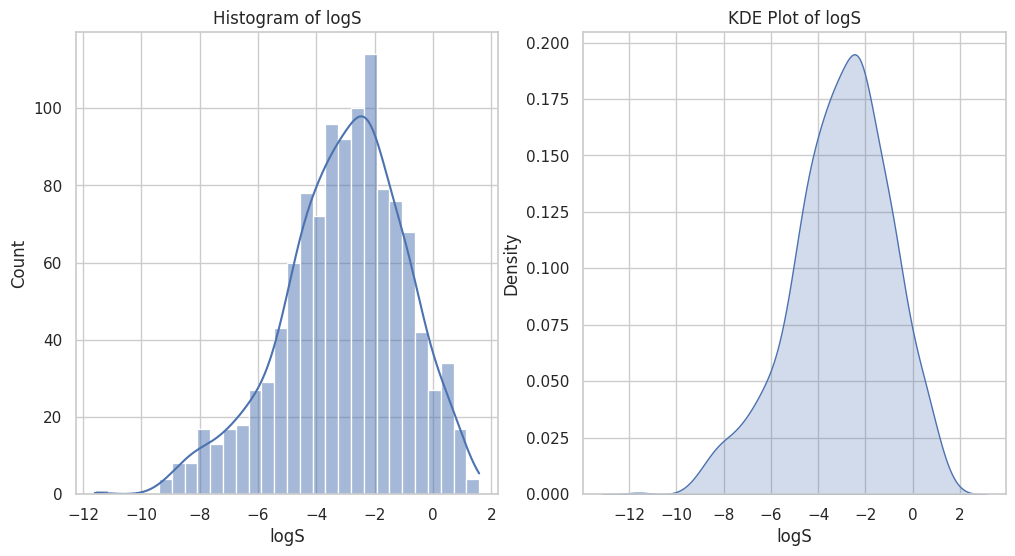

In [14]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['logS'], bins=30, kde=True)
plt.title('Histogram of logS')

plt.subplot(1, 2, 2)
sns.kdeplot(df['logS'], fill=True)
plt.title('KDE Plot of logS')
plt.show()

## Outliers Using IQR

In [15]:
print("Outliers using IQR:")
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
print(((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum())

Outliers using IQR:
MolLogP               57
MolWt                 10
NumRotatableBonds     54
AromaticProportion     0
logS                  14
dtype: int64


# Univariate Analysis Conclusion

### The dataset contains several variables with varying distributions. Skewness and kurtosis values indicate the presence of non-normal distributions, and box plots reveal outliers in some variables

### Skewness and kurtosis values indicate the presence of non-normal distributions, and box plots reveal outliers in some variables.

# MULTIVARIATE ANALYSIS

In [16]:
corr = df.corr()

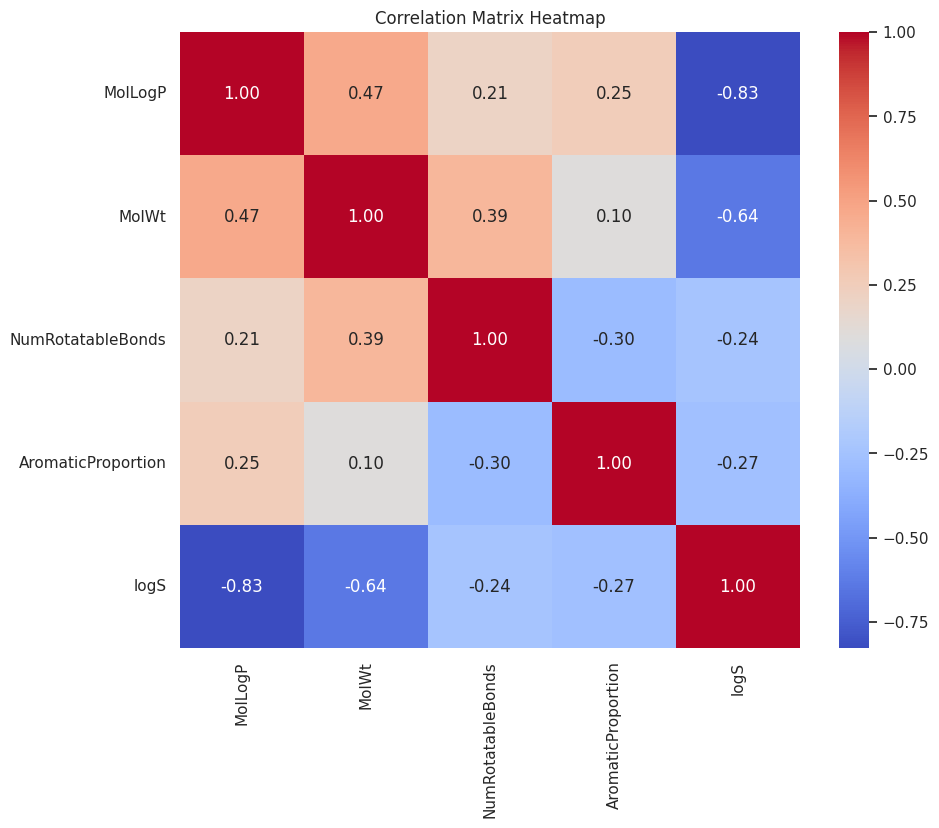

In [17]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.show()

# Random Forest

### Using a Random Forest model to identify the most important features for predicting 'logS'.

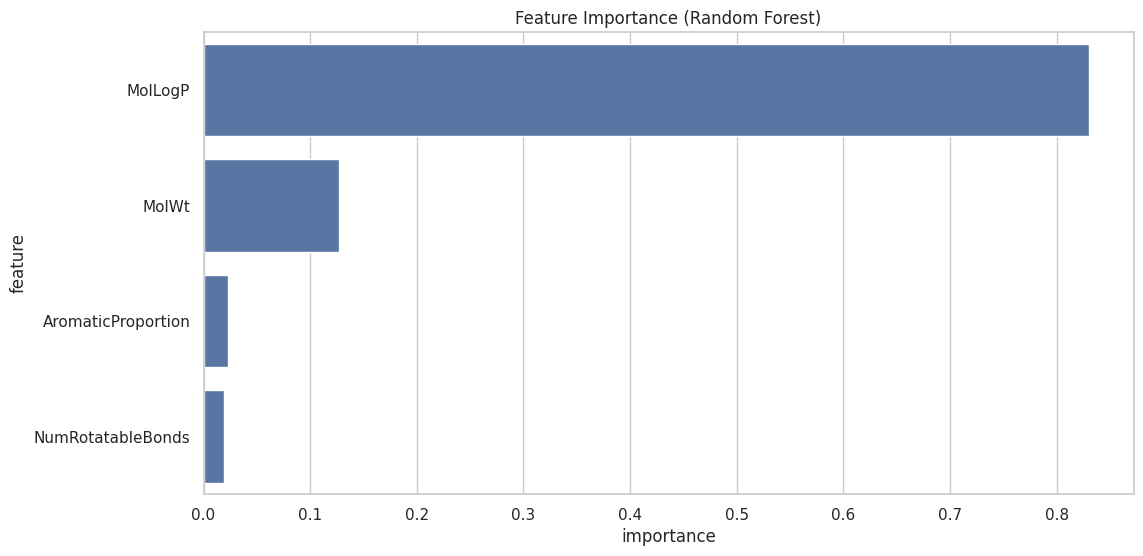

In [18]:
from sklearn.ensemble import RandomForestRegressor

X = df.drop(columns=['logS'])
y = df['logS']

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})

plt.figure(figsize=(12, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_df.sort_values(by='importance', ascending=False))
plt.title('Feature Importance (Random Forest)')
plt.show()

# Pair Grid

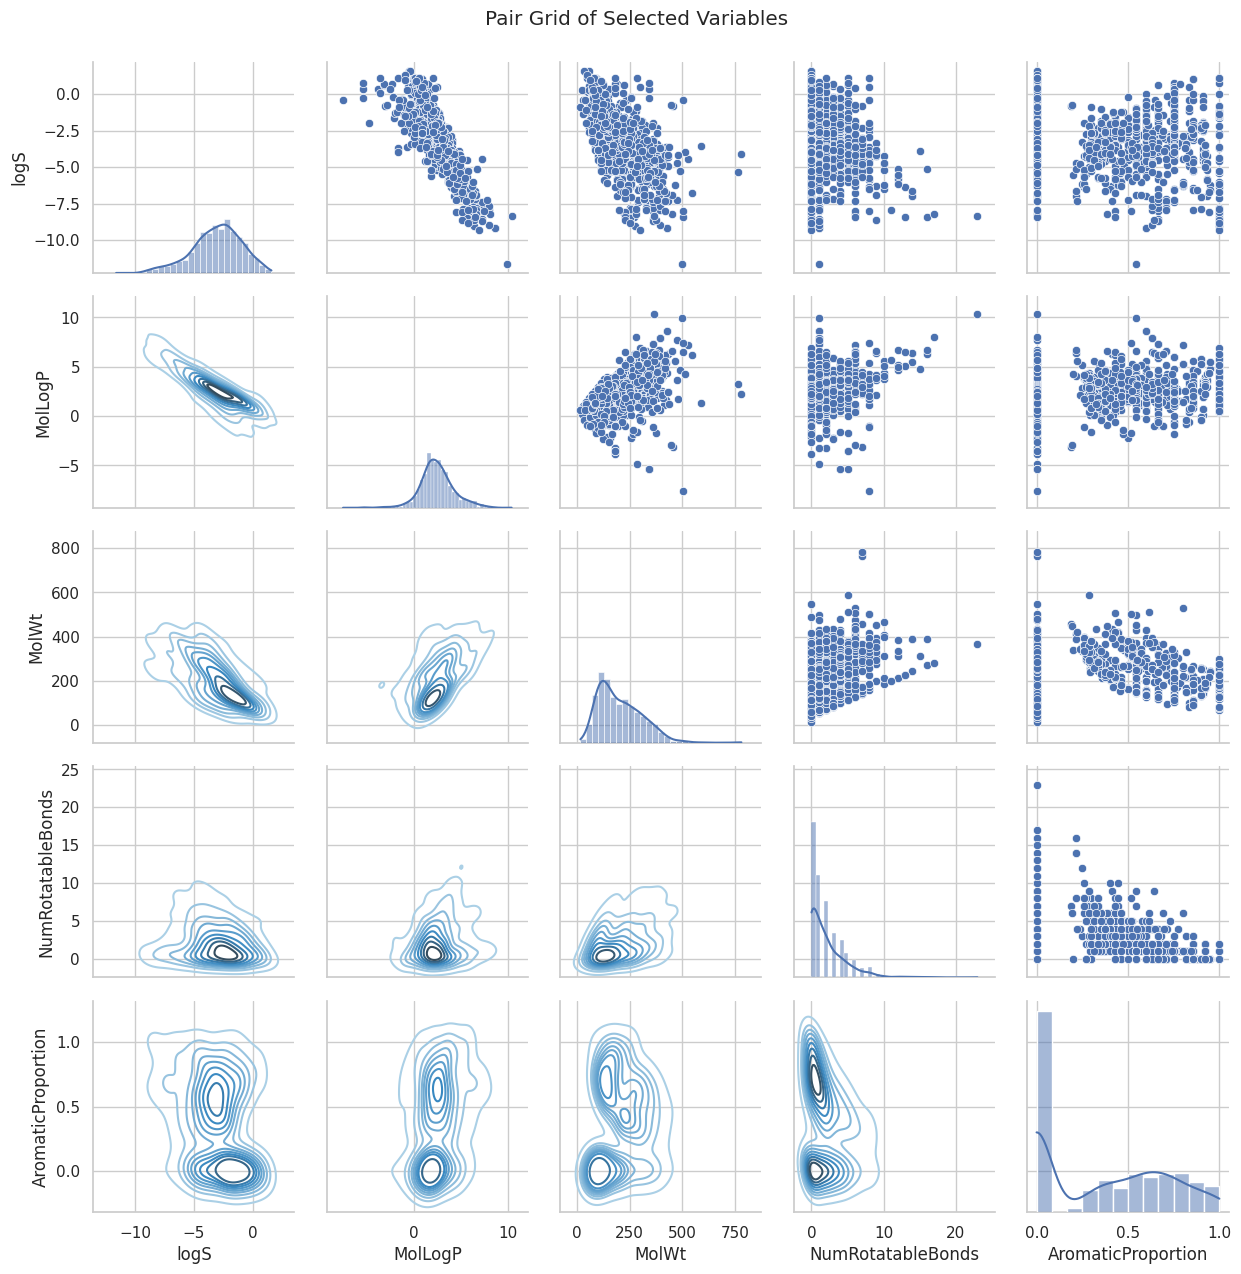

In [19]:
selected_columns = ['logS', 'MolLogP', 'MolWt', 'NumRotatableBonds', 'AromaticProportion']
pair_grid = sns.PairGrid(df[selected_columns])
pair_grid.map_upper(sns.scatterplot)
pair_grid.map_lower(sns.kdeplot, cmap='Blues_d')
pair_grid.map_diag(sns.histplot, kde=True)
plt.suptitle('Pair Grid of Selected Variables', y=1.02)
plt.show()

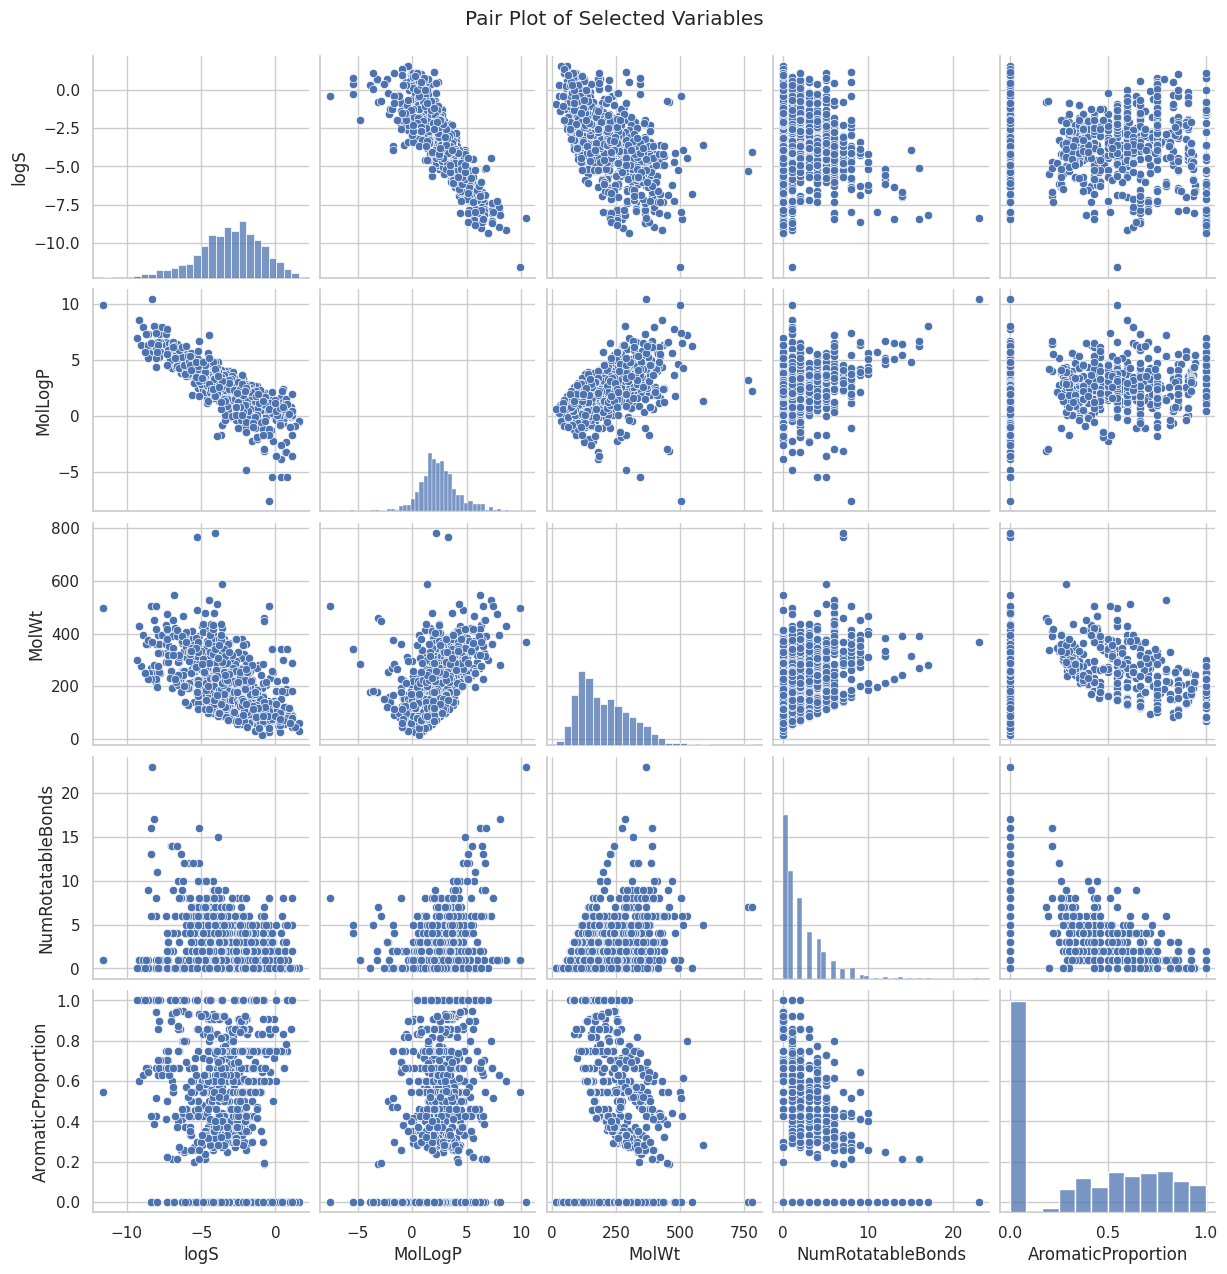

In [20]:
selected_columns = ['logS', 'MolLogP', 'MolWt', 'NumRotatableBonds', 'AromaticProportion']
if all(col in df.columns for col in selected_columns):
    sns.pairplot(df[selected_columns])
    plt.suptitle('Pair Plot of Selected Variables', y=1.02)
    plt.show()
else:
    print('One or more selected columns are not available in the dataset.')

In [21]:
features = [col for col in df.columns if col != 'logS']

# Scatter plot

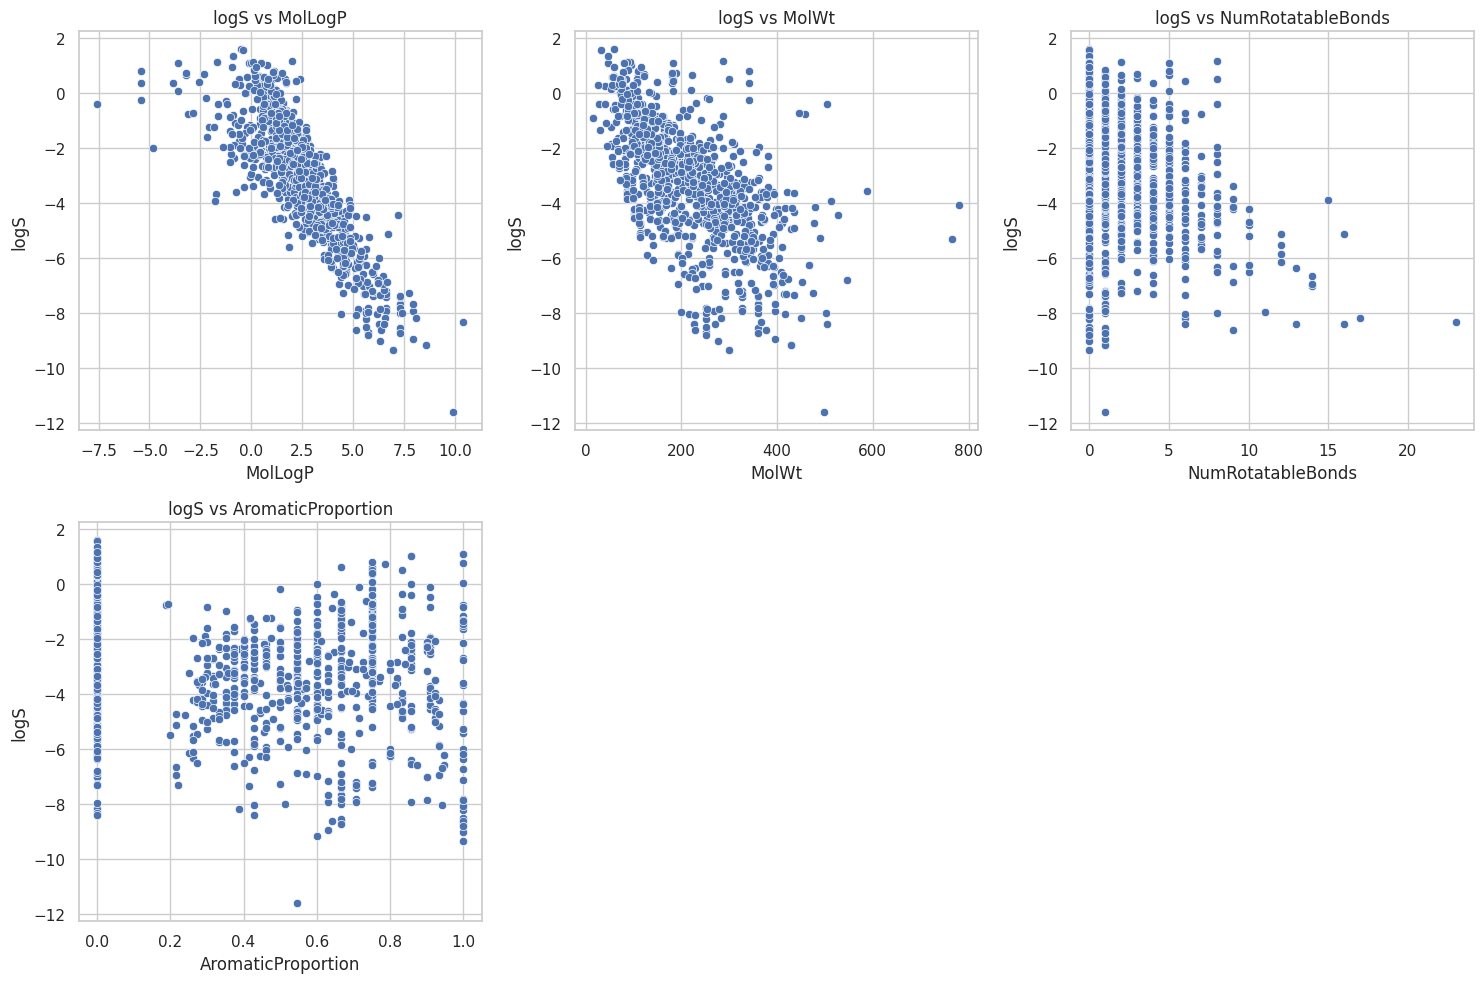

In [22]:
plt.figure(figsize=(15, 10))
for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.scatterplot(x=df[feature], y=df['logS'])
    plt.xlabel(feature)
    plt.ylabel('logS')
    plt.title(f'logS vs {feature}')
plt.tight_layout()
plt.show()

# Faceted histograms

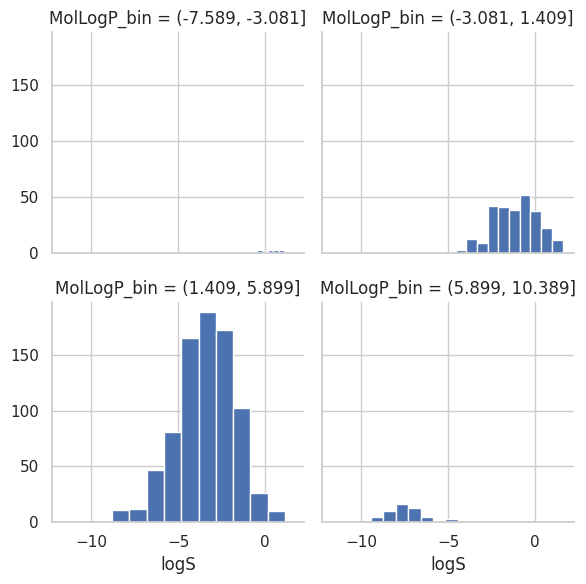

In [23]:
df['MolLogP_bin'] = pd.cut(df['MolLogP'], bins=4)
facet = sns.FacetGrid(df, col="MolLogP_bin", col_wrap=2, height=3, aspect=1)
facet.map(plt.hist, "logS")
plt.show()

# 3D Scatter plot

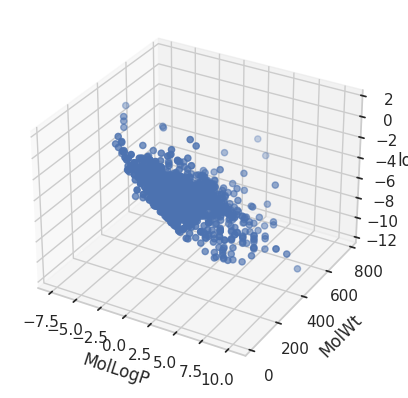

In [24]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['MolLogP'], df['MolWt'], df['logS'])
ax.set_xlabel('MolLogP')
ax.set_ylabel('MolWt')
ax.set_zlabel('logS')
plt.show()

# Hypothesis Testing

## T-Test

### T-test for Significant Differences: Perform a t-test to check for significant differences in 'logS' between different groups if any categorical variables exist

In [25]:
from scipy.stats import ttest_ind

group1 = df[df['MolLogP'] <= df['MolLogP'].median()]['logS']
group2 = df[df['MolLogP'] > df['MolLogP'].median()]['logS']

t_stat, p_value = ttest_ind(group1, group2)
print(f'T-test: t-statistic = {t_stat}, p-value = {p_value}')

T-test: t-statistic = 33.250858352239746, p-value = 4.171591538950977e-170


# Model Evaluation

### Spliting the data into train and test sets, training a model, and evaluating its performance using metrics like RMSE and R².

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
# Calculate MSE first
mse = mean_squared_error(y_test, y_pred)
# Then calculate RMSE by taking the square root
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f'RMSE: {rmse}, R²: {r2}')

RMSE: 0.6926489459918026, R²: 0.889824807388066


# Multivariate Analysis Conclusion

### The multivariate analysis reveals significant correlations between certain molecular descriptors and the target variable 'logS'. Pair plots and scatter plots provide insights into these relationships, while the correlation matrix highlights the strength of these associations. Further analysis may involve predictive modeling using these descriptors.